MULTI-LAYER PERCEPTRON FROM SCRATCH
Adapted from original notebook from Vítor Gama Lemos

[kaggle-notebook](https://www.kaggle.com/code/vitorgamalemos/multilayer-perceptron-from-scratch)


In [62]:
import random
import seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator, ClassifierMixin

seaborn.set(style='whitegrid'); seaborn.set_context('talk')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from sklearn.datasets import load_iris
iris_data = load_iris()

In [63]:
print(iris_data['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Number of samples: 150
Number of features: 4 



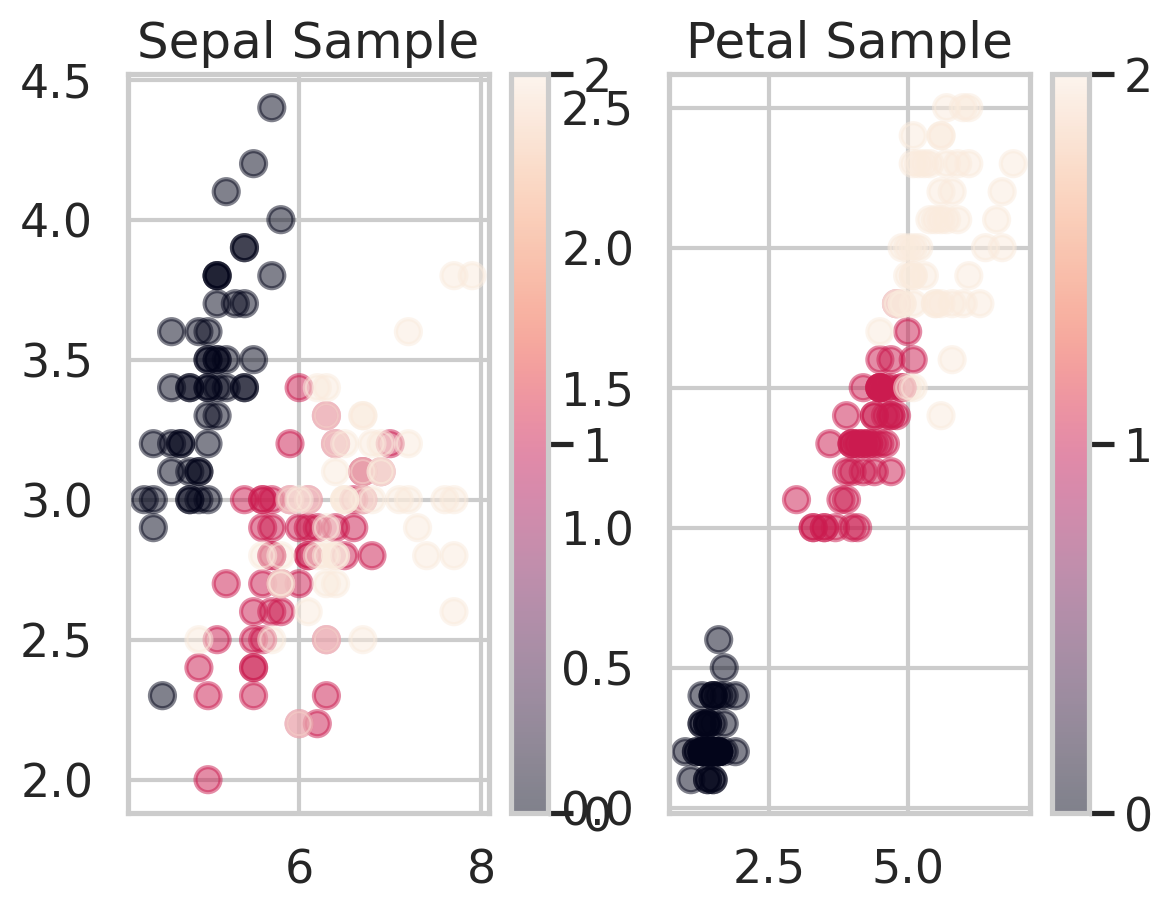

In [64]:
n_samples, n_features = iris_data.data.shape

print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features} \n")

plt.subplot(1, 2, 1)
scatter_plot = plt.scatter(iris_data.data[:,0], iris_data.data[:,1], alpha=0.5,
                           c=iris_data.target)
plt.colorbar(ticks=([0, 1, 2]))
plt.title('Sepal Sample');

plt.subplot(1, 2, 2)
scatter_plot_2 = plt.scatter(iris_data.data[:,2], iris_data.data[:,3], alpha=0.5,
                           c=iris_data.target)
plt.colorbar(ticks=([0, 1, 2]))
plt.title('Petal Sample');

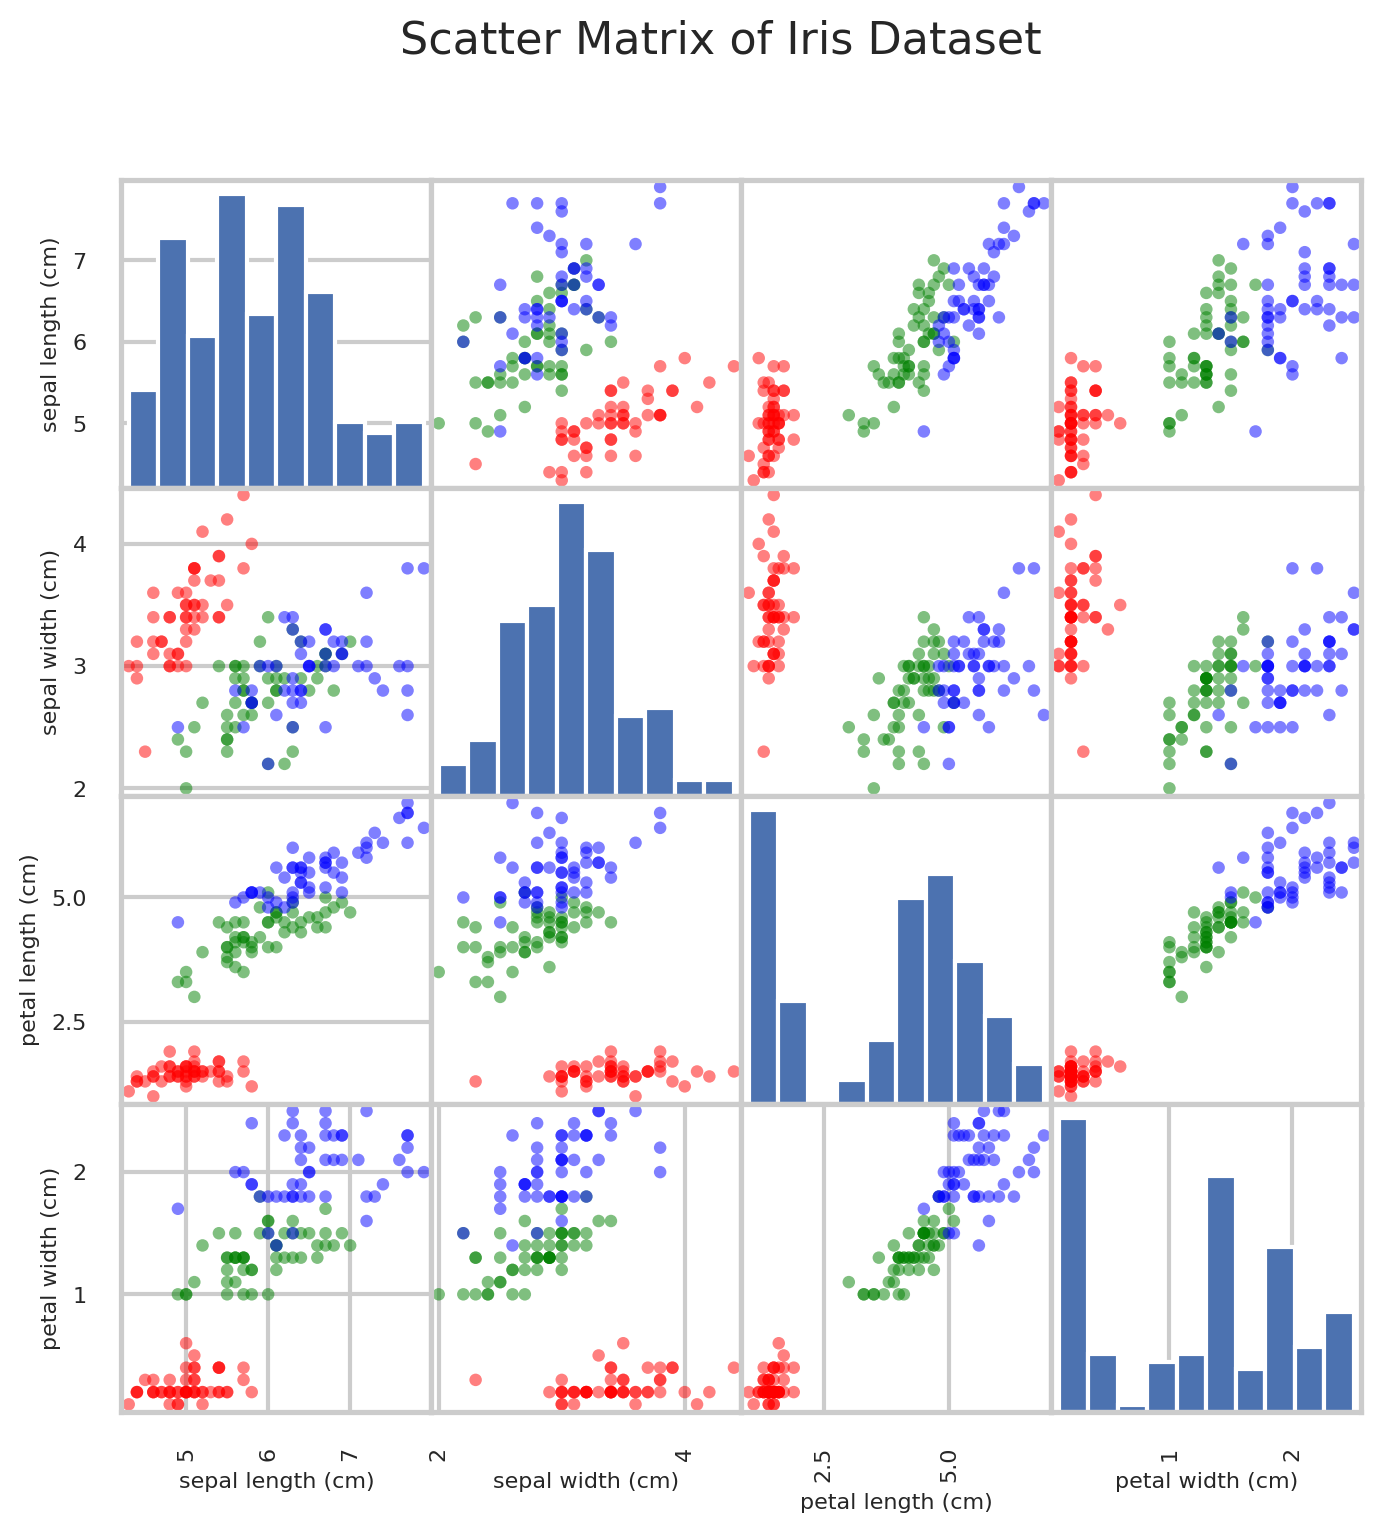

In [65]:
import pandas
from pandas.plotting import scatter_matrix


# Cria um DataFrame com os dados e os nomes das colunas
df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
df['target'] = iris_data.target

# Mapeia os números das classes para nomes legíveis
target_names = iris_data.target_names
df['target_name'] = df['target'].apply(lambda i: target_names[i])

# Escolhe uma paleta de cores
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}
df['color'] = df['target_name'].map(colors)

# Gera o scatter_matrix
axes = scatter_matrix(df[iris_data.feature_names],
               figsize=(8, 8),
               diagonal='hist',
               color=df['color'],
               alpha=0.5)

# Reduz o tamanho da fonte dos rótulos dos eixos
for ax in axes.ravel():
    ax.set_xlabel(ax.get_xlabel(), fontsize=8)
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)

plt.suptitle("Scatter Matrix of Iris Dataset", fontsize=16)
plt.show()

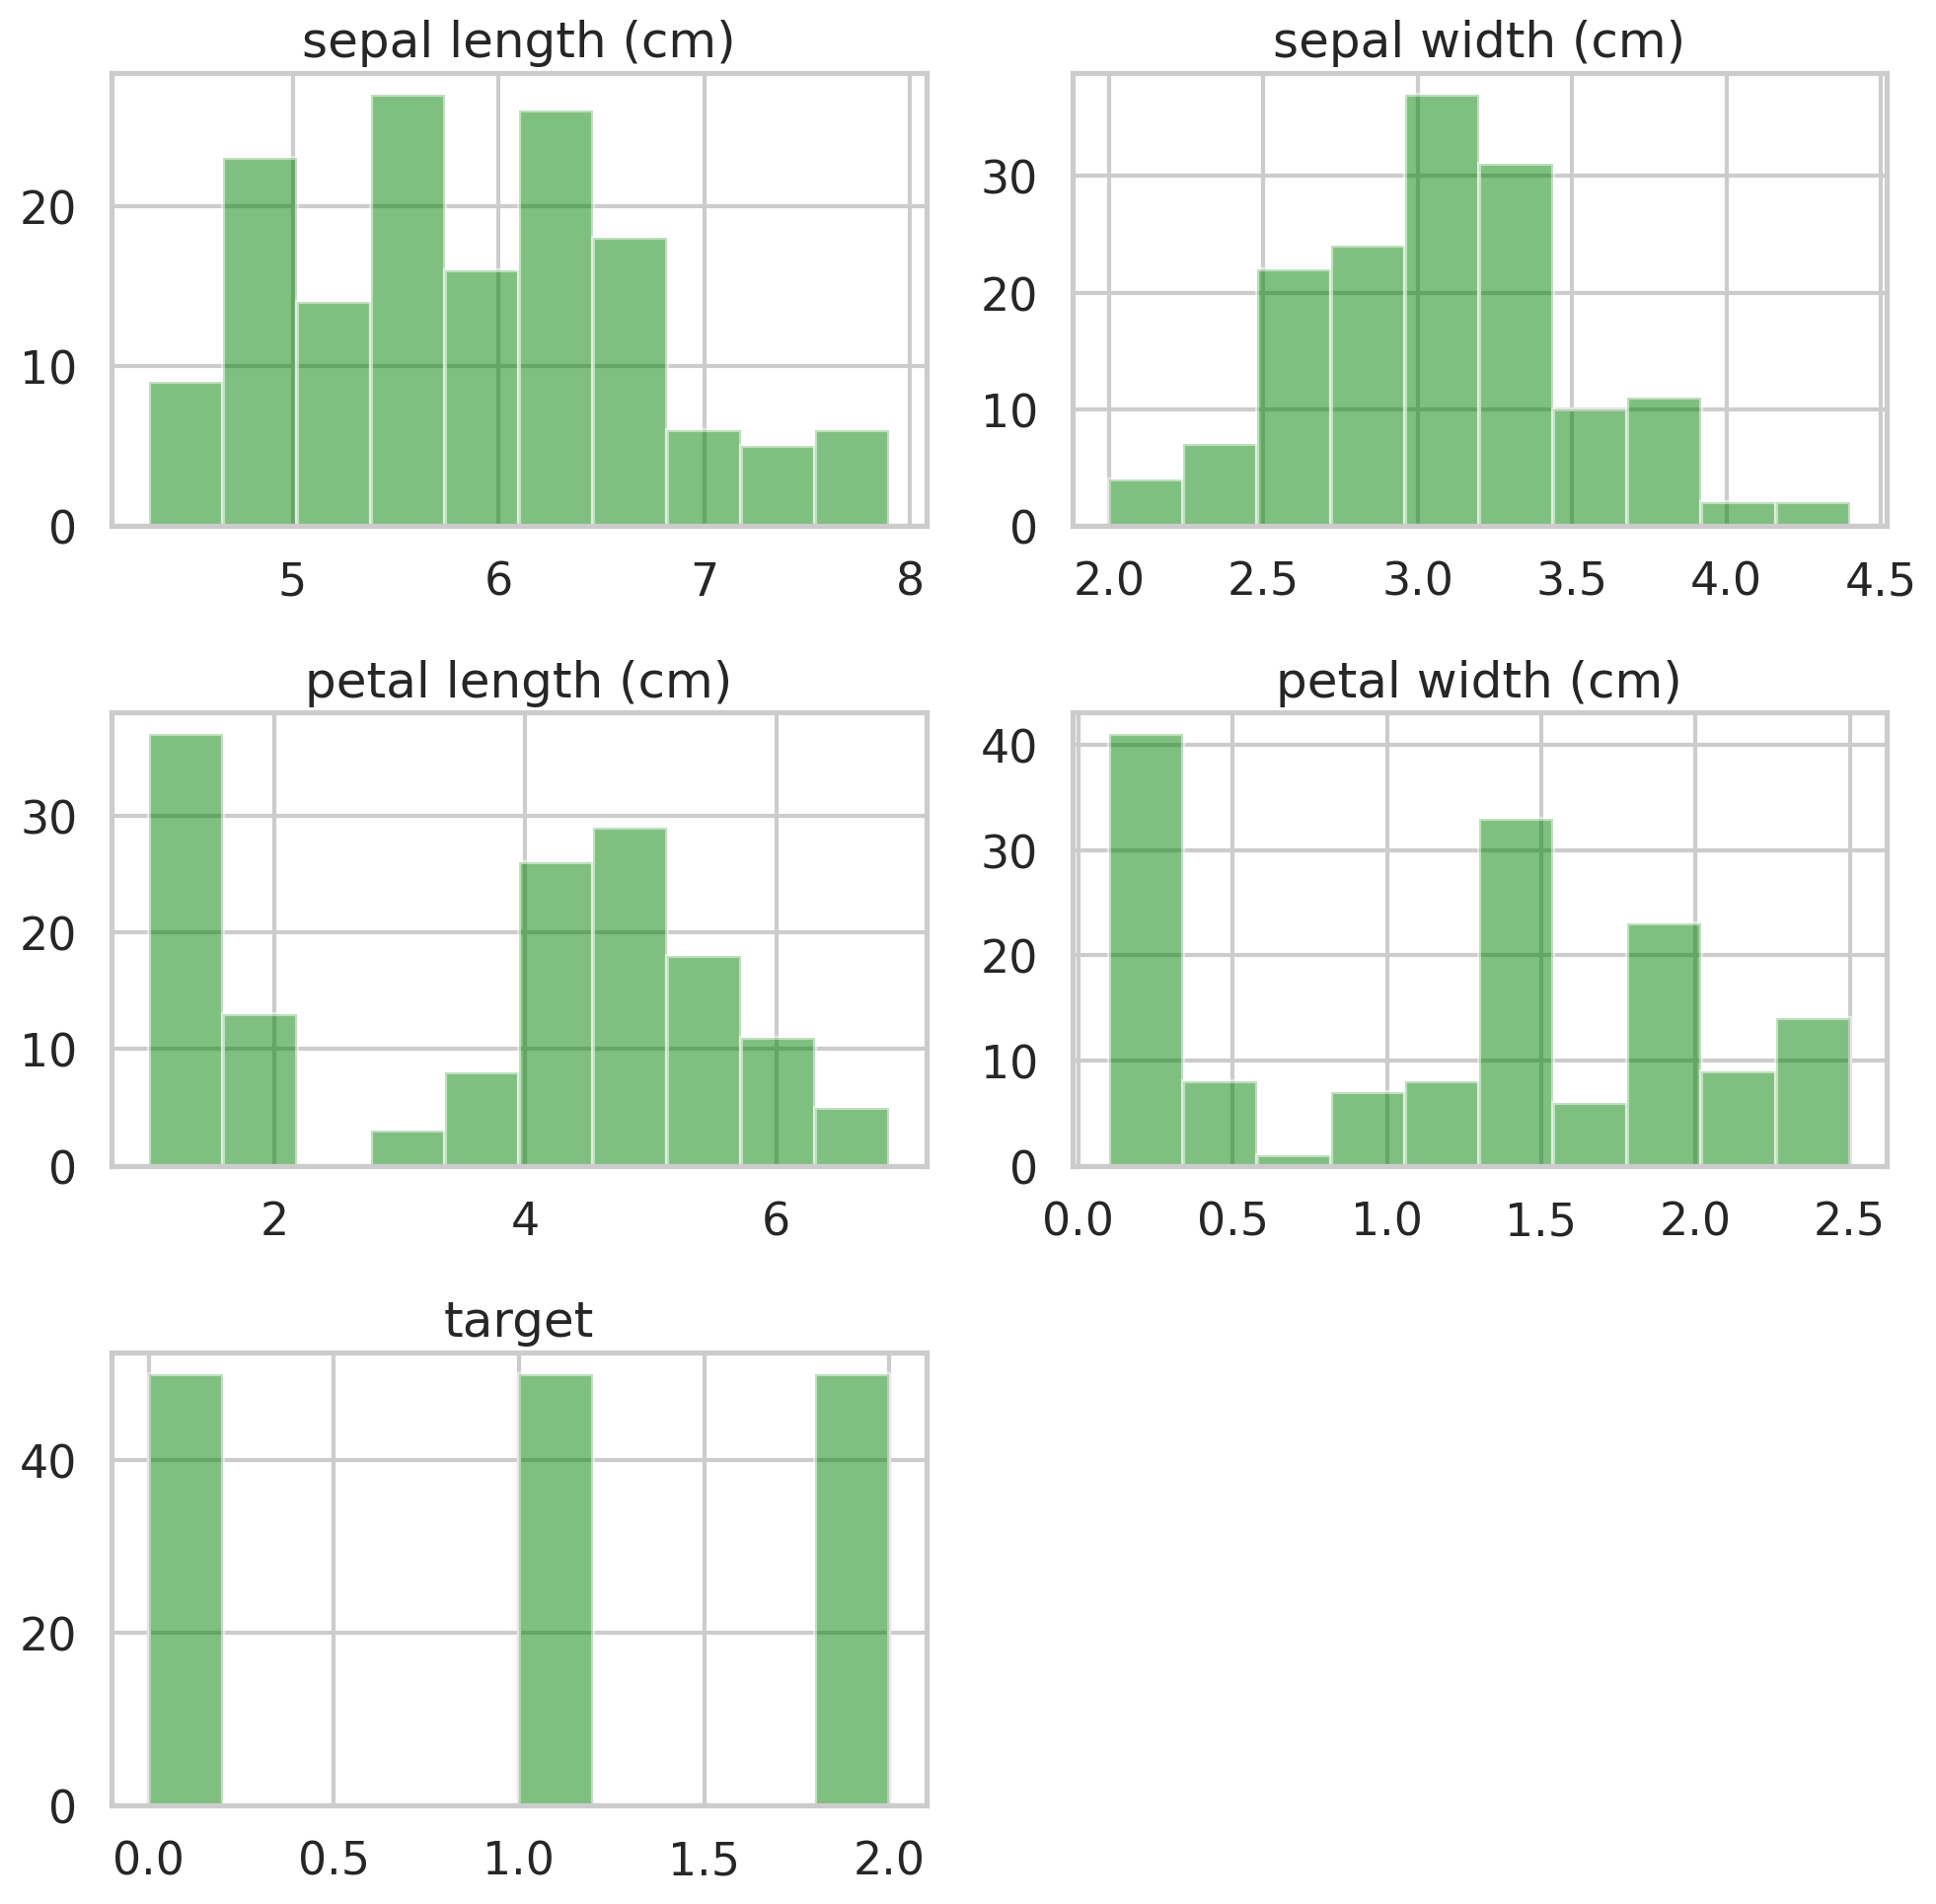

In [66]:
axes = df.hist(alpha=0.5, figsize=(10, 10), color='green')

plt.tight_layout()
plt.show()

In [67]:
# Separando features (X) e labels (y) do objeto 'iris_data' carregado no início
X = iris_data.data
y = iris_data.target

# Garante reprodutibilidade e proporções de classes iguais em todos os conjuntos (stratify=y)

# 1. Separa 20% para o conjunto de teste final
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Separa os 80% restantes em treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Amostras de Treino: {len(X_train)}")
print(f"Amostras de Validação: {len(X_val)}")
print(f"Amostras de Teste: {len(X_test)}")

Amostras de Treino: 90
Amostras de Validação: 30
Amostras de Teste: 30


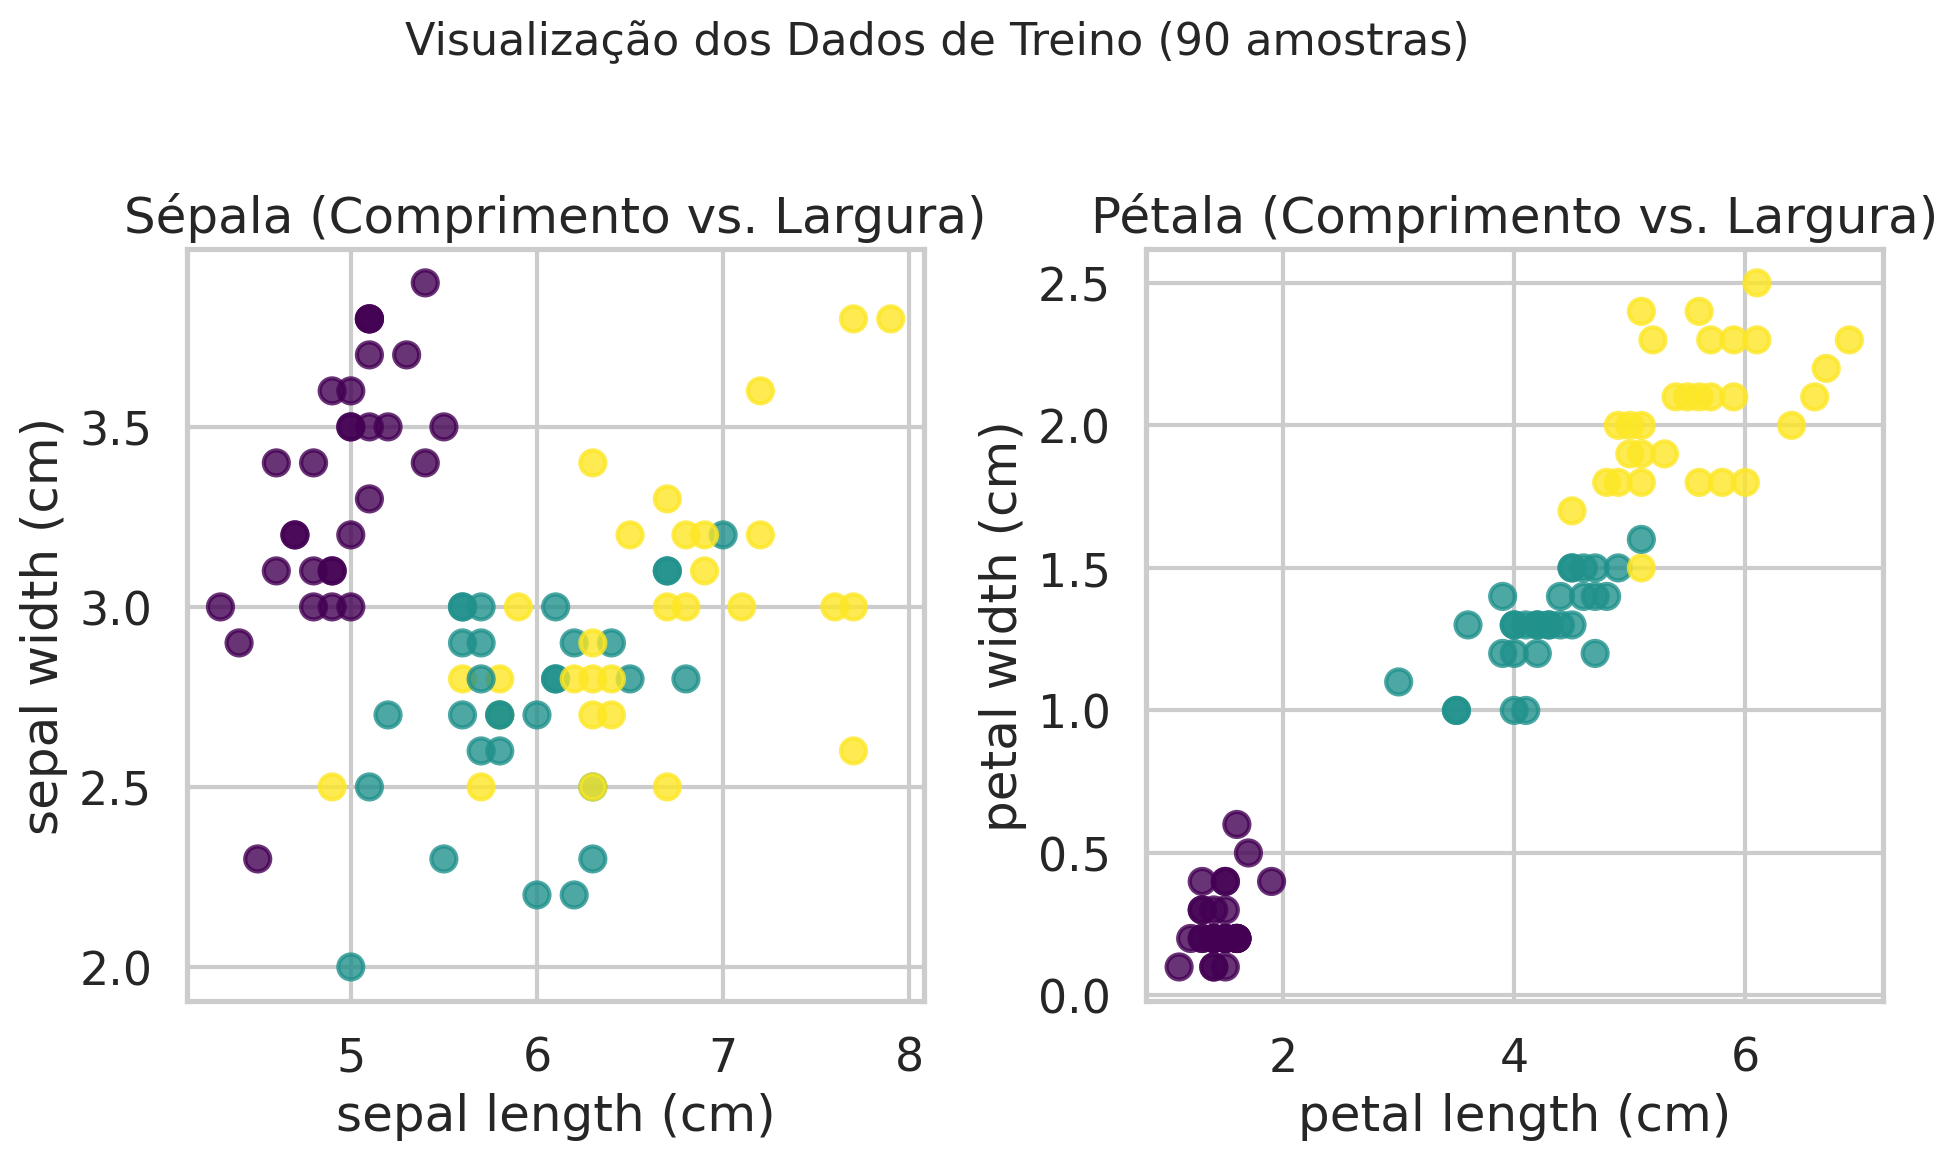

In [68]:
# Criando uma figura maior para acomodar os dois gráficos
plt.figure(figsize=(10, 6))

# Título geral para a figura
plt.suptitle('Visualização dos Dados de Treino (90 amostras)', fontsize=16)

# Gráfico 1: Sépala
plt.subplot(1, 2, 1)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap=cm.viridis, alpha=0.8)
plt.title('Sépala (Comprimento vs. Largura)')
plt.xlabel(iris_data.feature_names[0])
plt.ylabel(iris_data.feature_names[1])
plt.grid(True)

# Gráfico 2: Pétala
plt.subplot(1, 2, 2)
plt.scatter(X_train[:,2], X_train[:,3], c=y_train, cmap=cm.viridis, alpha=0.8)
plt.title('Pétala (Comprimento vs. Largura)')
plt.xlabel(iris_data.feature_names[2])
plt.ylabel(iris_data.feature_names[3])
plt.grid(True)

# Ajusta o layout para evitar sobreposição de títulos
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

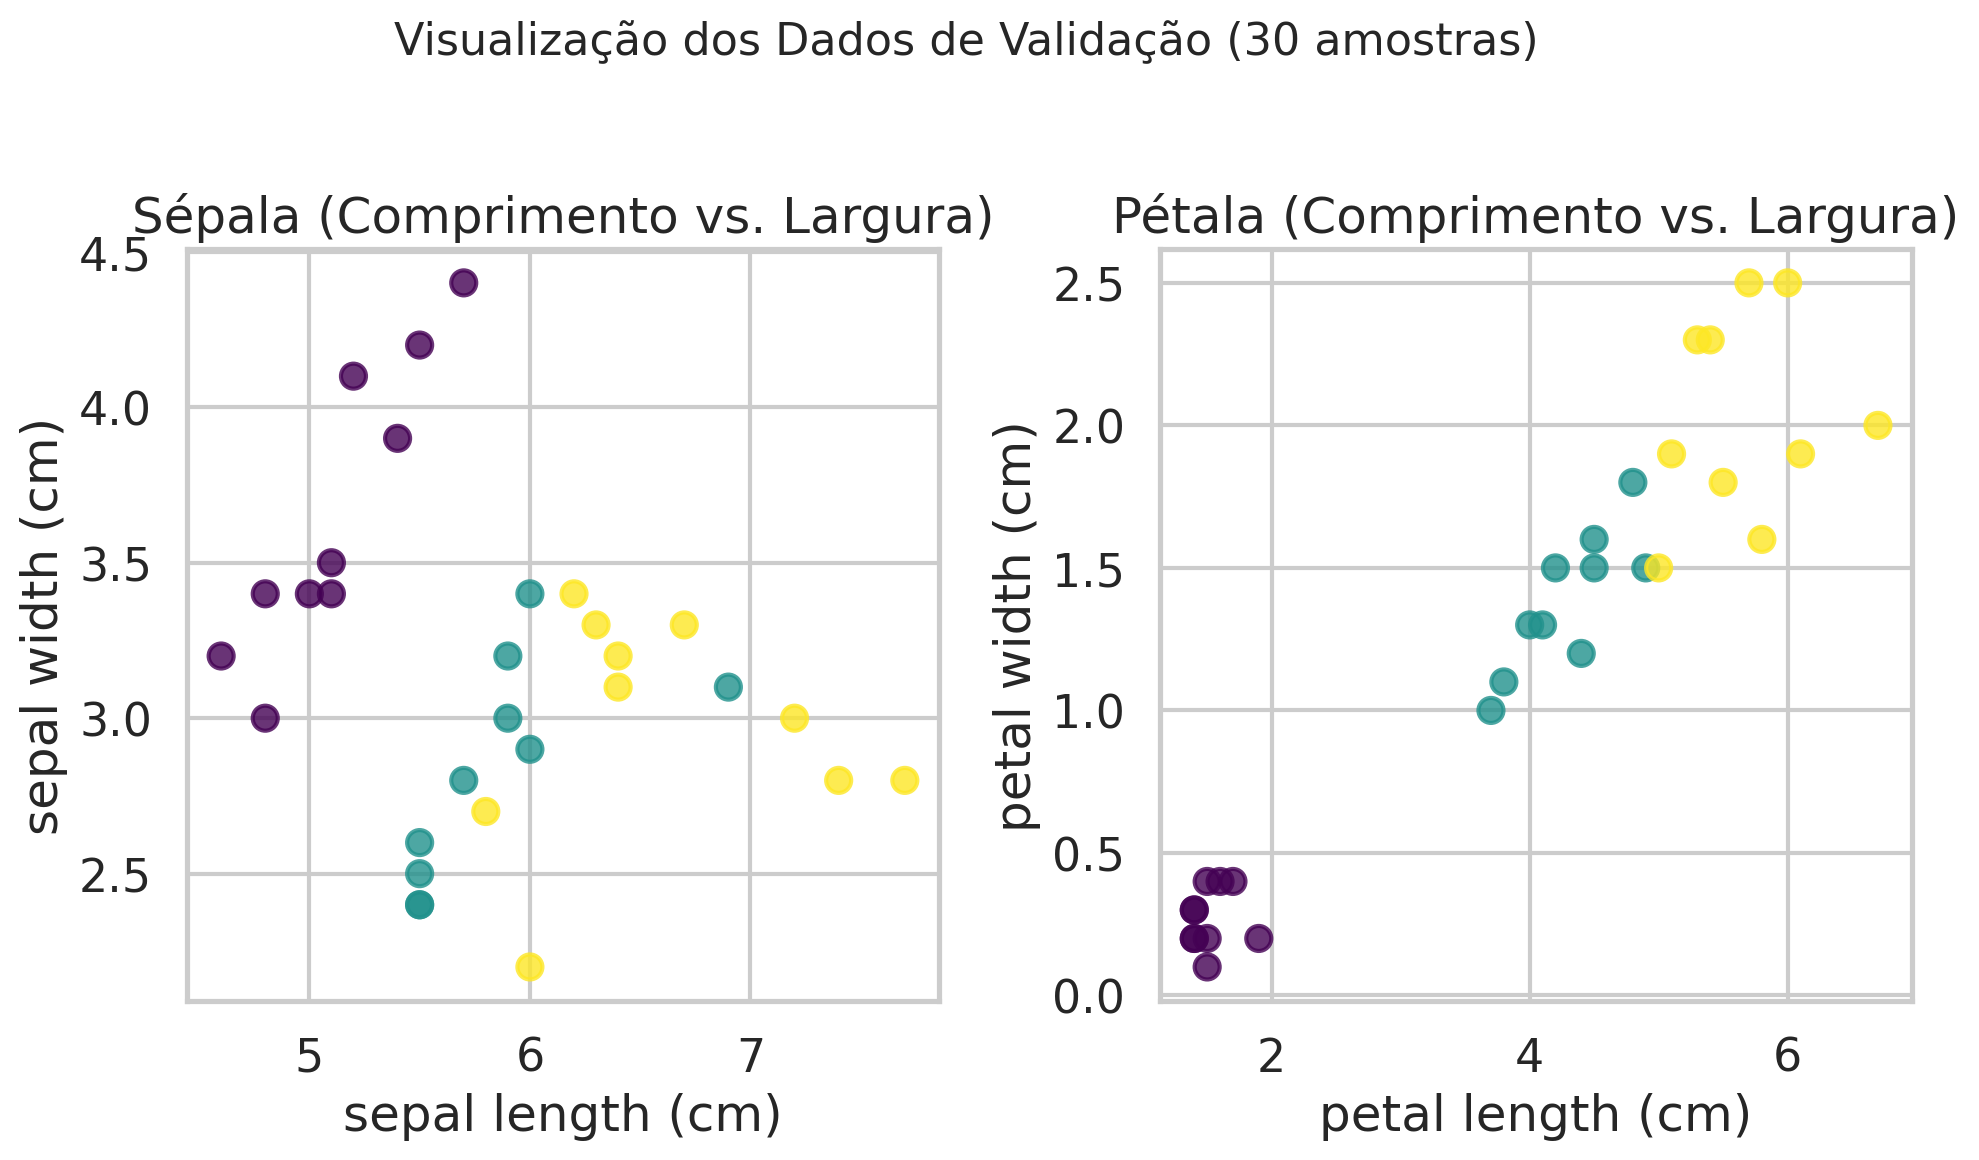

In [69]:
# Criando uma figura maior para os gráficos de validação
plt.figure(figsize=(10, 6))

# Título geral para a figura
plt.suptitle('Visualização dos Dados de Validação (30 amostras)', fontsize=16)

# Gráfico 1: Sépala
plt.subplot(1, 2, 1)
plt.scatter(X_val[:,0], X_val[:,1], c=y_val, cmap=cm.viridis, alpha=0.8)
plt.title('Sépala (Comprimento vs. Largura)')
plt.xlabel(iris_data.feature_names[0])
plt.ylabel(iris_data.feature_names[1])
plt.grid(True)

# Gráfico 2: Pétala
plt.subplot(1, 2, 2)
plt.scatter(X_val[:,2], X_val[:,3], c=y_val, cmap=cm.viridis, alpha=0.8)
plt.title('Pétala (Comprimento vs. Largura)')
plt.xlabel(iris_data.feature_names[2])
plt.ylabel(iris_data.feature_names[3])
plt.grid(True)

# Ajusta o layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

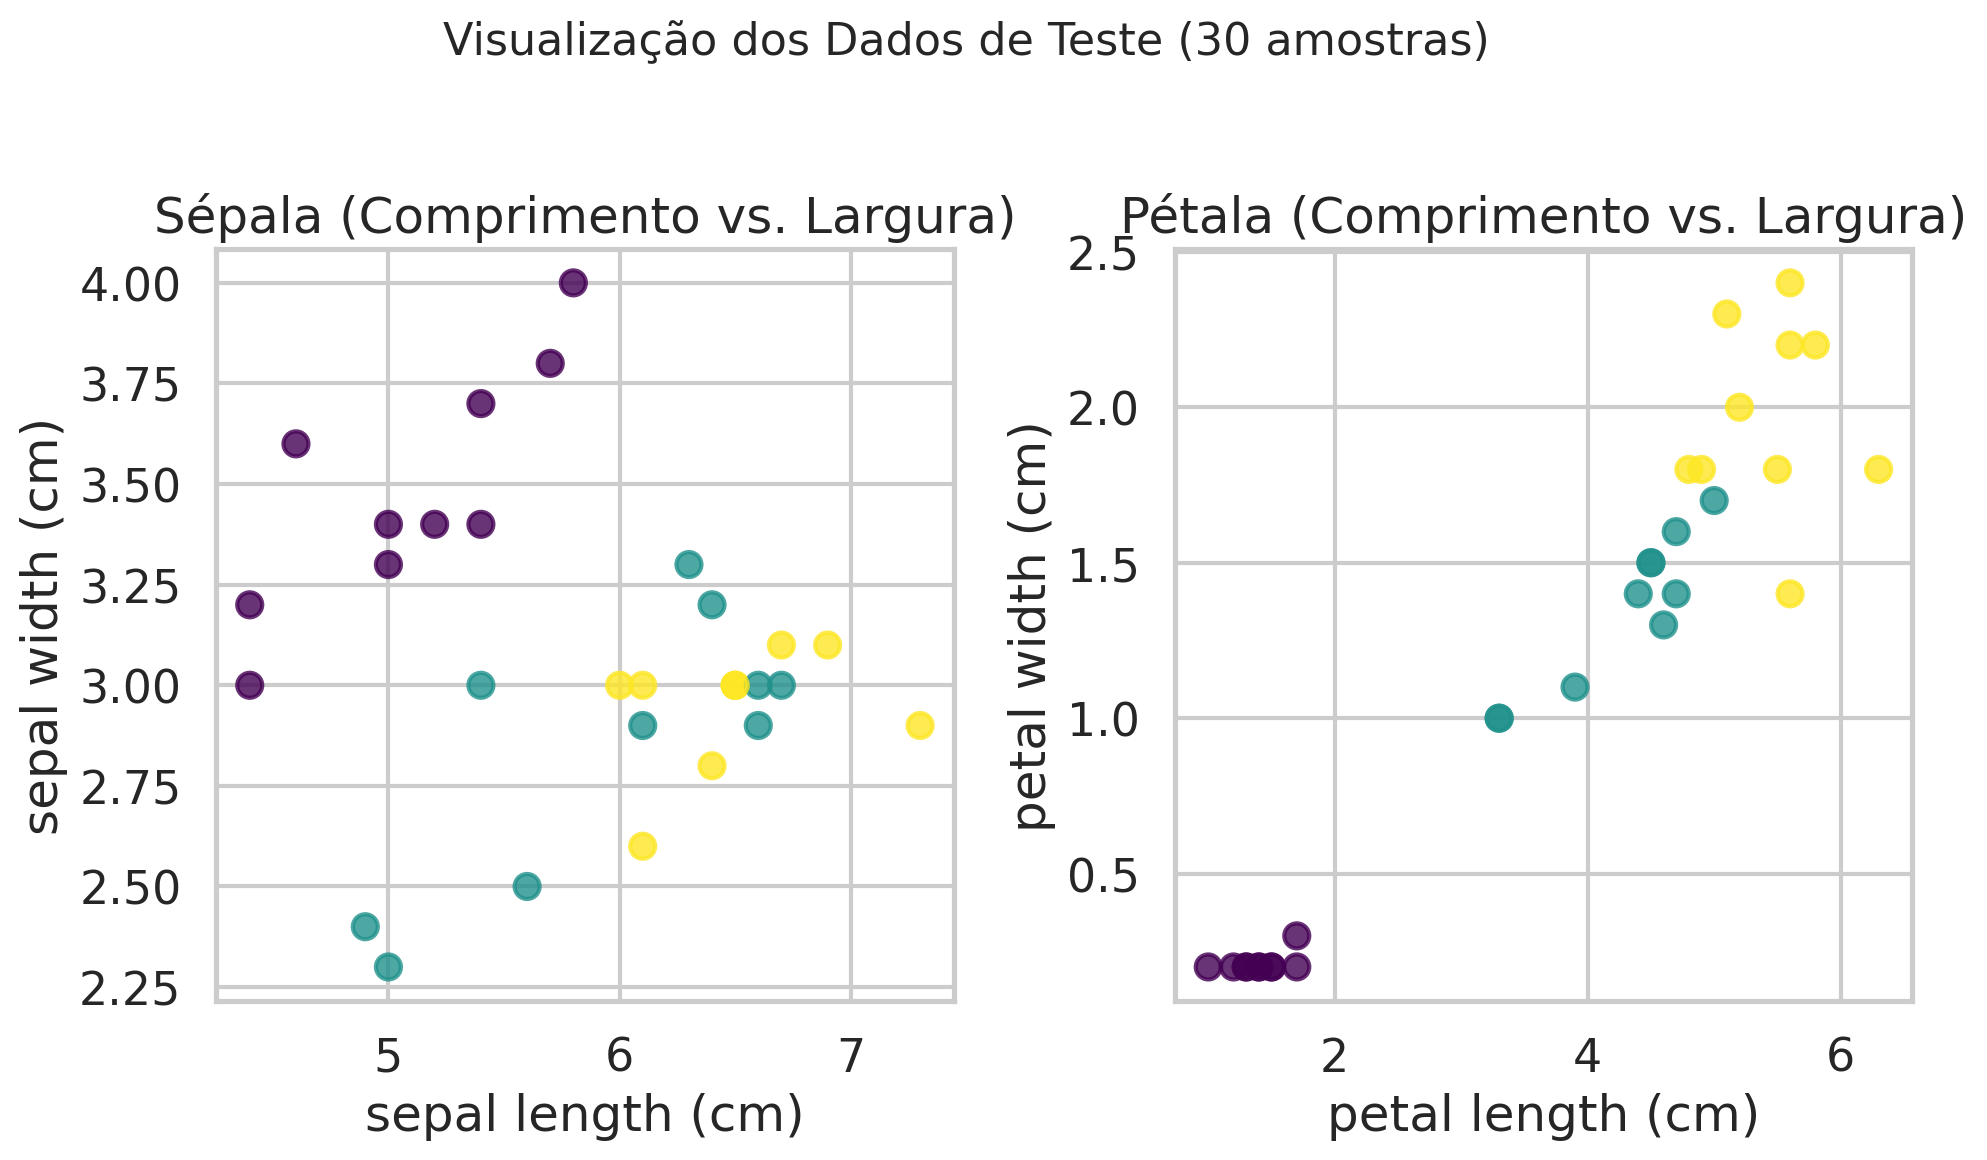

In [70]:
# Criando uma figura maior para os gráficos de teste
plt.figure(figsize=(10, 6))

# Título geral para a figura
plt.suptitle('Visualização dos Dados de Teste (30 amostras)', fontsize=16)

# Gráfico 1: Sépala
plt.subplot(1, 2, 1)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=cm.viridis, alpha=0.8)
plt.title('Sépala (Comprimento vs. Largura)')
plt.xlabel(iris_data.feature_names[0])
plt.ylabel(iris_data.feature_names[1])
plt.grid(True)

# Gráfico 2: Pétala
plt.subplot(1, 2, 2)
plt.scatter(X_test[:,2], X_test[:,3], c=y_test, cmap=cm.viridis, alpha=0.8)
plt.title('Pétala (Comprimento vs. Largura)')
plt.xlabel(iris_data.feature_names[2])
plt.ylabel(iris_data.feature_names[3])
plt.grid(True)

# Ajusta o layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [71]:
from sklearn.base import BaseEstimator, ClassifierMixin
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class MultiLayerPerceptron(BaseEstimator, ClassifierMixin):
    ativacao = {
        'sigmoid': (lambda x: 1/(1 + np.exp(-x))),
        'tanh': (lambda x: np.tanh(x)),
        'Relu': (lambda x: x*(x > 0)),
    }
    derivada = {
        'sigmoid': (lambda x: x*(1-x)),
        'tanh': (lambda x: 1-x**2),
        'Relu': (lambda x: 1 * (x>0))
    }

    def __init__(self, params=None):
        self.params = params
        
        if (params == None):
            self.inputLayer = 4
            self.hiddenLayer = 5
            self.outputLayer = 3
            self.learningRate = 0.005
            self.max_epochs = 3000
            self.BiasHiddenValue = -1
            self.BiasOutputValue = -1
            self.activation = self.ativacao['sigmoid']
            self.deriv = self.derivada['sigmoid']
        else:
            self.inputLayer = params['InputLayer']
            self.hiddenLayer = params['HiddenLayer']
            self.outputLayer = params['OutputLayer']
            self.learningRate = params['LearningRate']
            self.max_epochs = params['Epocas']
            self.BiasHiddenValue = params['BiasHiddenValue']
            self.BiasOutputValue = params['BiasOutputValue']
            self.activation = self.ativacao[params['ActivationFunction']]
            self.deriv = self.derivada[params['ActivationFunction']]

        random.seed(42); np.random.seed(42)
        self.WEIGHT_hidden = self.starting_weights(self.inputLayer, self.hiddenLayer)
        self.WEIGHT_output = self.starting_weights(self.hiddenLayer, self.outputLayer)
        self.BIAS_hidden = np.full(self.hiddenLayer, self.BiasHiddenValue, dtype=float)
        self.BIAS_output = np.full(self.outputLayer, self.BiasOutputValue, dtype=float)
        self.classes_number = 3

    def starting_weights(self, rows, columns):
        return [[2 * random.random() - 1 for _ in range(columns)] for _ in range(rows)]

    def Backpropagation_Algorithm(self, x):
        ERROR_output = self.output - self.OUTPUT_L2
        DELTA_output = ((-1)*ERROR_output)
        for i in range(self.hiddenLayer):
            for j in range(self.outputLayer):
                self.WEIGHT_output[i][j] -= (self.learningRate * (DELTA_output[j] * self.OUTPUT_L1[i]))
        for j in range(self.outputLayer):
                self.BIAS_output[j] -= (self.learningRate * DELTA_output[j])
        delta_hidden = np.matmul(self.WEIGHT_output, DELTA_output) * self.deriv(self.OUTPUT_L1)
        for i in range(self.inputLayer):
            for j in range(self.hiddenLayer):
                self.WEIGHT_hidden[i][j] -= (self.learningRate * (delta_hidden[j] * x[i]))
        for j in range(self.hiddenLayer):
            self.BIAS_hidden[j] -= (self.learningRate * delta_hidden[j])

    def show_err_graphic(self, train_error_array, val_error_array, epoch_array):
        plt.figure(figsize=(12,6))
        epochs_to_plot_train = [e for e in epoch_array if e <= len(val_error_array)]
        plt.plot(epochs_to_plot_train, train_error_array, 'b-', marker='o', label='Erro de Treino')
        val_epochs = range(1, len(val_error_array) + 1)
        plt.plot(val_epochs, val_error_array, 'r-', marker='.', markersize=4, linestyle='--', label='Erro de Validação')
        plt.axvline(x=len(val_error_array), color='k', linestyle=':', label=f'Parada Antecipada na Época {len(val_error_array)}')
        plt.xlabel("Número de Épocas"); plt.ylabel("Erro Quadrático (MSE)"); plt.title("Minimização do Erro (Treino vs. Validação)")
        plt.legend(); plt.grid(True); plt.xlim(0, len(val_error_array) + 50); plt.show()

    def fit(self, X, y, X_val, y_val):
        # early stopping helpers
        patience = 100
        patience_counter = 0
        best_val_error = float('inf')

        # salva uma cópia inicial dos melhores pesos
        best_WEIGHT_hidden = [w.copy() for w in self.WEIGHT_hidden]
        best_WEIGHT_output = [w.copy() for w in self.WEIGHT_output]
        best_BIAS_hidden = self.BIAS_hidden.copy()
        best_BIAS_output = self.BIAS_output.copy()
        
        # variáveis para os gráficos
        count_epoch = 1
        n = len(X)
        epoch_array, train_error_array, val_error_array = [], [], []
        
        # para guardar o histórico de um peso específico
        weight_hidden_plot = []
        weight_output_plot = []

        while(count_epoch <= self.max_epochs):
            total_error = 0
            for idx, inputs in enumerate(X):
                # forward propagation
                self.output = np.zeros(self.classes_number)
                self.OUTPUT_L1 = self.activation((np.dot(inputs, self.WEIGHT_hidden) + self.BIAS_hidden))
                self.OUTPUT_L2 = (np.dot(self.OUTPUT_L1, self.WEIGHT_output) + self.BIAS_output)

                # one-hot encoding do target
                if(y[idx] == 0): self.output = np.array([1,0,0])
                elif(y[idx] == 1): self.output = np.array([0,1,0])
                else: self.output = np.array([0,0,1])

                # cálculo do erro e backpropagation
                square_error = 0.5 * np.sum((self.output - self.OUTPUT_L2)**2)
                total_error += square_error
                self.Backpropagation_Algorithm(inputs)
            
            # lógica de validação e early stopping 
            val_hidden_output = self.activation(np.matmul(X_val, self.WEIGHT_hidden) + self.BIAS_hidden)
            val_scores = np.matmul(val_hidden_output, self.WEIGHT_output) + self.BIAS_output
            y_val_one_hot = np.eye(self.classes_number)[y_val.astype(int)]
            val_error = np.mean(0.5 * (y_val_one_hot - val_scores)**2)
            val_error_array.append(val_error)
            
            # checa se o erro de validação melhorou
            if val_error < best_val_error:
                best_val_error = val_error
                patience_counter = 0
                best_WEIGHT_hidden = [w.copy() for w in self.WEIGHT_hidden]
                best_WEIGHT_output = [w.copy() for w in self.WEIGHT_output]
                best_BIAS_hidden = self.BIAS_hidden.copy()
                best_BIAS_output = self.BIAS_output.copy()
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"--- PARADA ANTECIPADA NA ÉPOCA {count_epoch}! ---")
                print(f"Melhor erro de validação: {best_val_error:.6f}")
                break
            
            # armazenamento de dados para os gráficos 
            mean_epoch_error = total_error / n
            if((count_epoch % 50 == 0) or (count_epoch == 1)):
                print(f"Época {count_epoch} - Erro Treino: {mean_epoch_error:.6f} - Erro Validação: {val_error:.6f}")
                train_error_array.append(mean_epoch_error)
                epoch_array.append(count_epoch)
                
                # guarda o valor de um peso de amostra para o gráfico
                weight_hidden_plot.append(self.WEIGHT_hidden[0][0])
                weight_output_plot.append(self.WEIGHT_output[0][0])
                
            count_epoch += 1
        
        print("\nRestaurando os melhores pesos encontrados...")
        self.WEIGHT_hidden = best_WEIGHT_hidden
        self.WEIGHT_output = best_WEIGHT_output
        self.BIAS_hidden = best_BIAS_hidden
        self.BIAS_output = best_BIAS_output
        
        self.show_err_graphic(train_error_array, val_error_array, epoch_array)
        
        plt.figure(figsize=(10, 5))
        plt.plot(epoch_array, weight_hidden_plot, color="g", marker='d')
        plt.title('Variação de um Peso (Entrada[0] -> Oculta[0])')
        plt.xlabel('Épocas')
        plt.ylabel('Valor do Peso')
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.plot(epoch_array, weight_output_plot, color="purple", marker='s')
        plt.title('Variação de um Peso (Oculta[0] -> Saída[0])')
        plt.xlabel('Épocas')
        plt.ylabel('Valor do Peso')
        plt.grid(True)
        plt.show()

        return self

    def predict(self, X):
        hidden_output = self.activation(np.matmul(X, self.WEIGHT_hidden) + self.BIAS_hidden)
        scores = np.matmul(hidden_output, self.WEIGHT_output) + self.BIAS_output
        return np.argmax(scores, axis=1)

Época 1 - Erro Treino: 1.358912 - Erro Validação: 0.227956
Época 50 - Erro Treino: 0.164144 - Erro Validação: 0.053777
Época 100 - Erro Treino: 0.153186 - Erro Validação: 0.049552
Época 150 - Erro Treino: 0.134064 - Erro Validação: 0.042717
Época 200 - Erro Treino: 0.106318 - Erro Validação: 0.033248
Época 250 - Erro Treino: 0.078291 - Erro Validação: 0.024079
Época 300 - Erro Treino: 0.058357 - Erro Validação: 0.017868
Época 350 - Erro Treino: 0.047155 - Erro Validação: 0.014623
Época 400 - Erro Treino: 0.041449 - Erro Validação: 0.013169
Época 450 - Erro Treino: 0.038484 - Erro Validação: 0.012569
Época 500 - Erro Treino: 0.036770 - Erro Validação: 0.012332
Época 550 - Erro Treino: 0.035623 - Erro Validação: 0.012241
Época 600 - Erro Treino: 0.034747 - Erro Validação: 0.012205
Época 650 - Erro Treino: 0.034014 - Erro Validação: 0.012189
Época 700 - Erro Treino: 0.033368 - Erro Validação: 0.012179
Época 750 - Erro Treino: 0.032783 - Erro Validação: 0.012170
Época 800 - Erro Treino: 0.

/tmp/ipykernel_28167/824549779.py:73: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(val_epochs, val_error_array, 'r-', marker='.', markersize=4, linestyle='--', label='Erro de Validação')


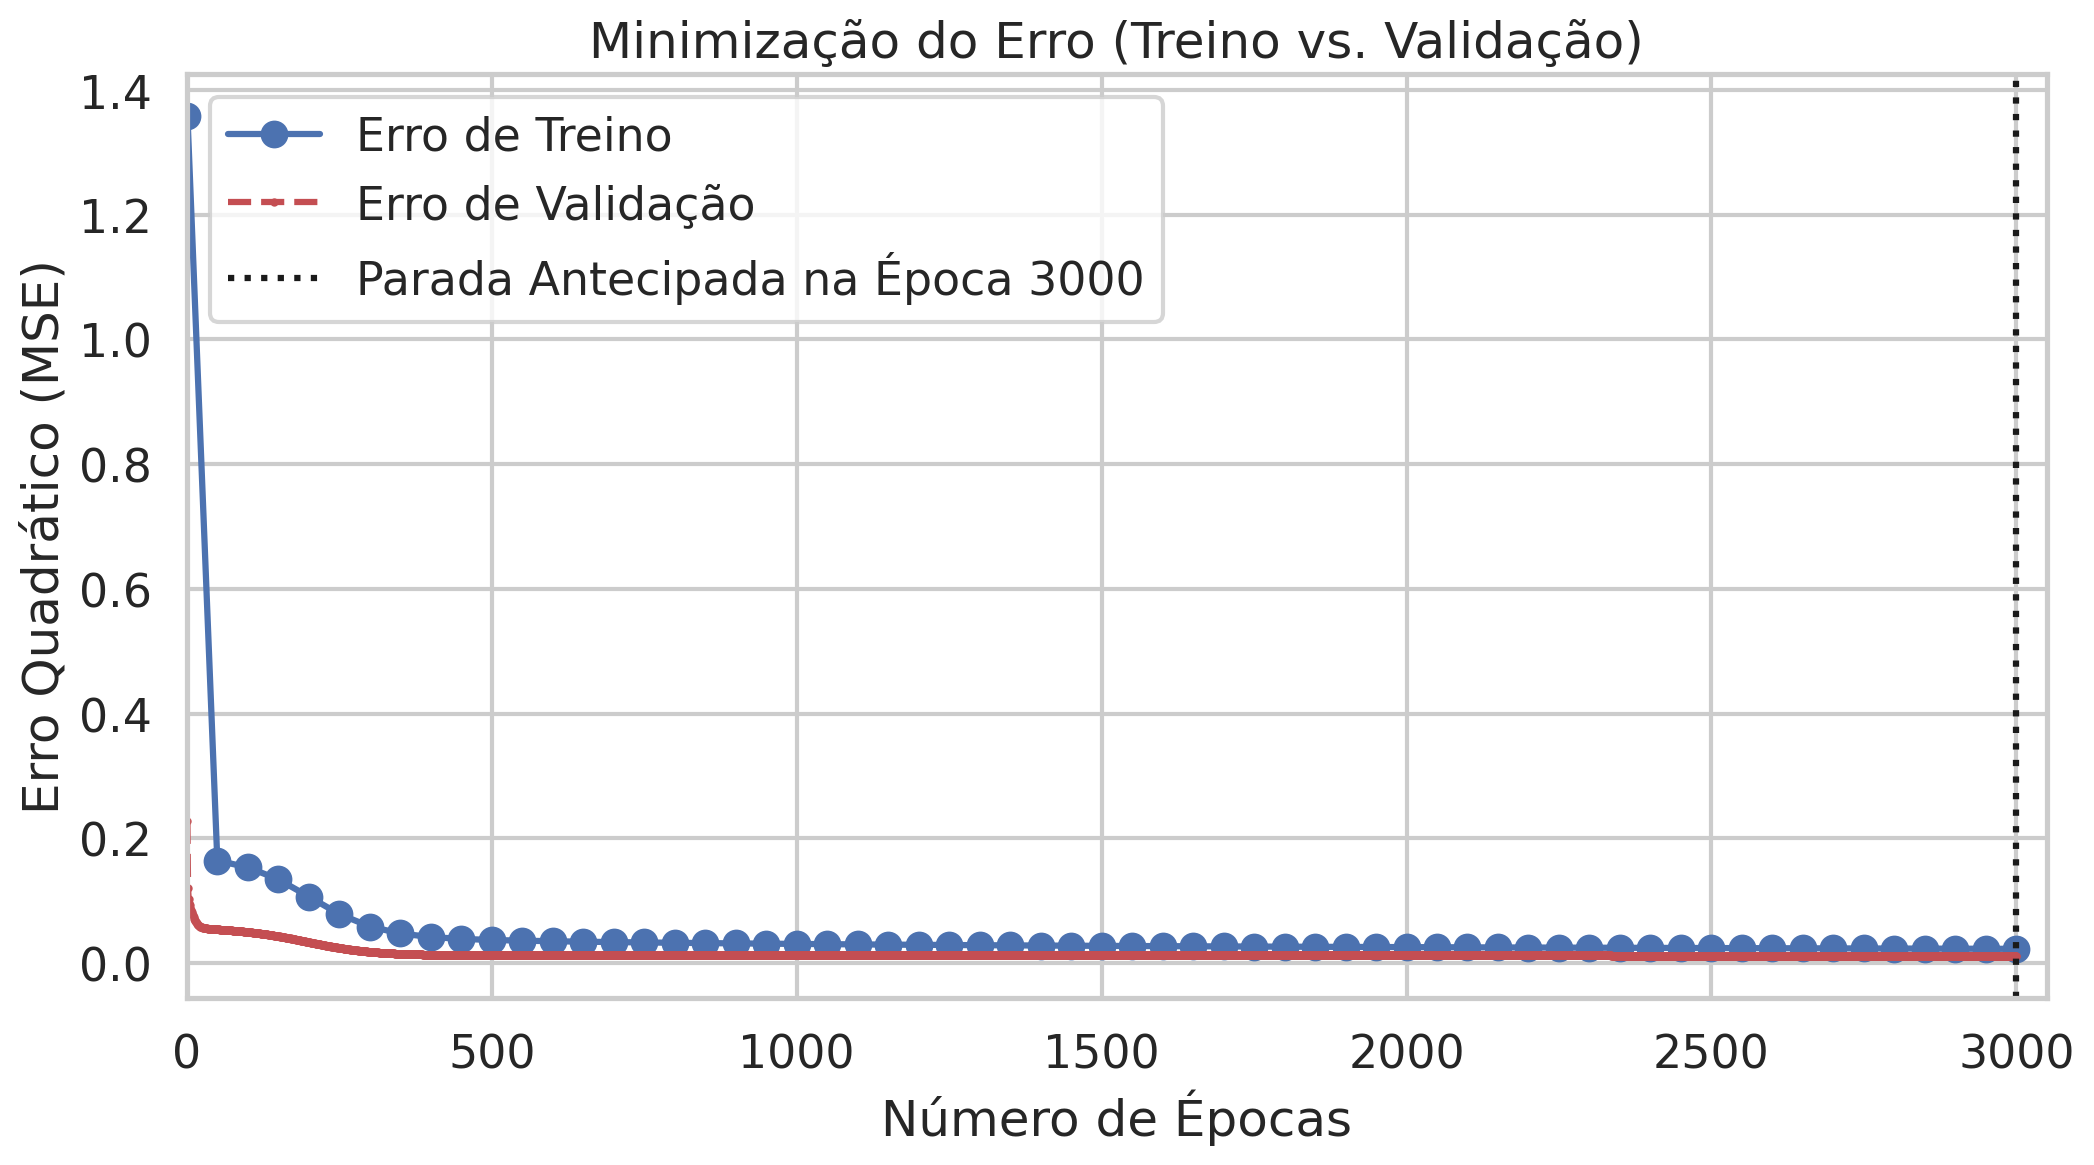

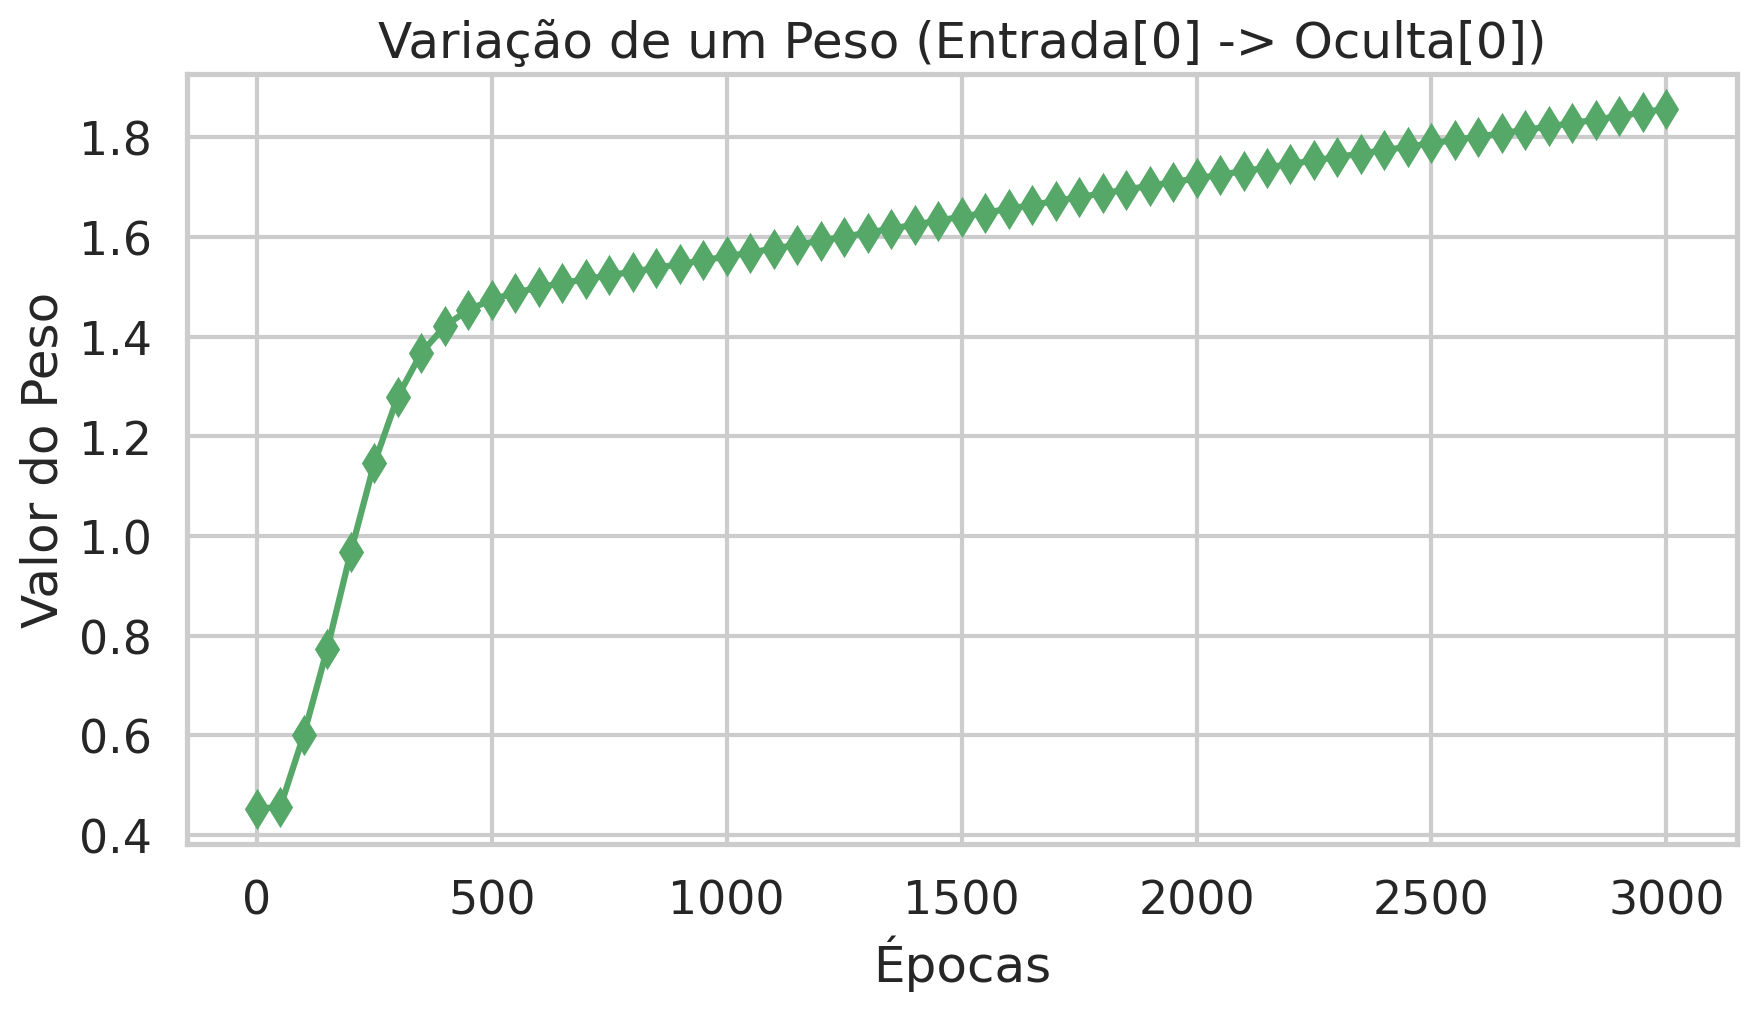

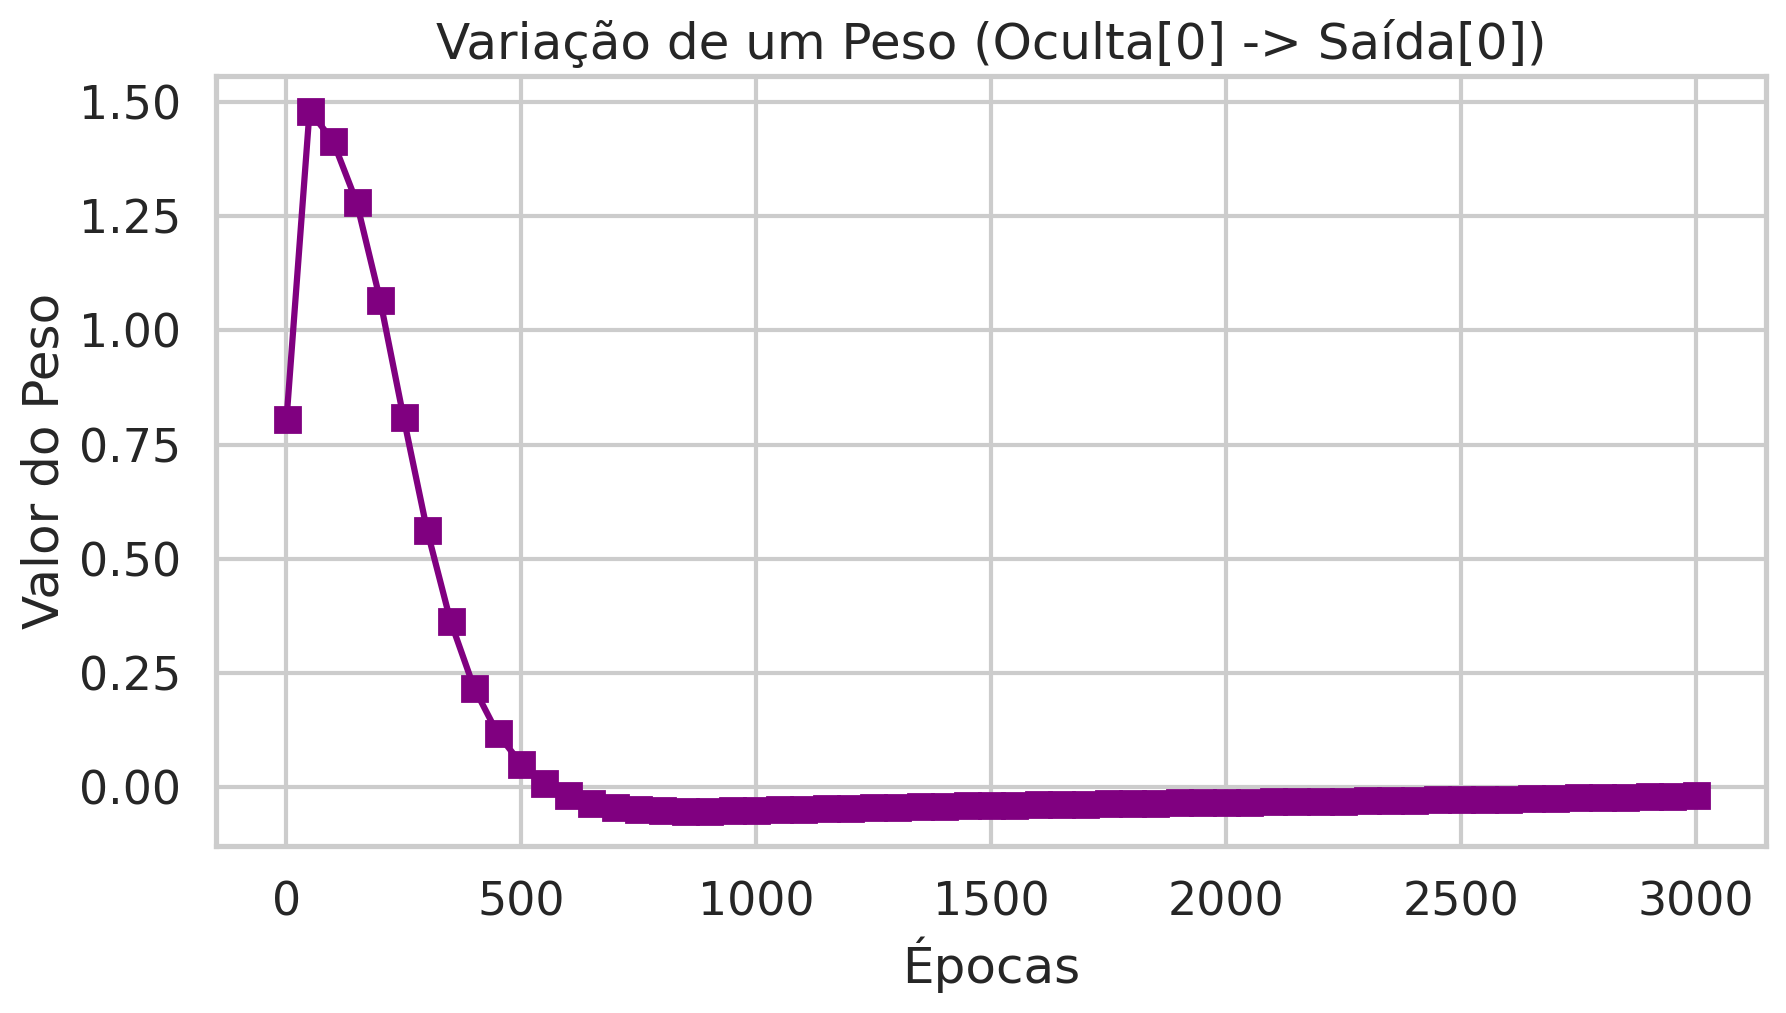

MultiLayerPerceptron(params={'ActivationFunction': 'sigmoid',
                             'BiasHiddenValue': -1, 'BiasOutputValue': -1,
                             'Epocas': 3000, 'HiddenLayer': 5, 'InputLayer': 4,
                             'LearningRate': 0.005, 'OutputLayer': 3})

In [72]:
dictionary = {'InputLayer':4, 'HiddenLayer':5, 'OutputLayer':3,
              'Epocas':3000, 'LearningRate':0.005,'BiasHiddenValue':-1,
              'BiasOutputValue':-1, 'ActivationFunction':'sigmoid'}

Perceptron = MultiLayerPerceptron(params=dictionary)

Perceptron.fit(X_train, y_train, X_val, y_val)

In [73]:
test_predictions = Perceptron.predict(X_test)

accuracy = accuracy_score(y_test, test_predictions)
print(f"\nAcurácia final no conjunto de teste: {accuracy * 100:.2f}%\n")

# mostra um DataFrame para análise de erros
df_results = pd.DataFrame({
    'Real': y_test,
    'Previsto': test_predictions
})
df_results['classe_real'] = df_results['Real'].apply(lambda i: iris_data.target_names[i])
df_results['classe_prevista'] = df_results['Previsto'].apply(lambda i: iris_data.target_names[i])

print("DataFrame de Resultados (Teste):")
print(df_results)

# previsões estavam incorretas
print("\nAmostras classificadas incorretamente:")
print(df_results[df_results['Real'] != df_results['Previsto']])


Acurácia final no conjunto de teste: 96.67%

DataFrame de Resultados (Teste):
    Real  Previsto classe_real classe_prevista
0      0         0      setosa          setosa
1      2         2   virginica       virginica
2      1         1  versicolor      versicolor
3      1         1  versicolor      versicolor
4      0         0      setosa          setosa
5      1         1  versicolor      versicolor
6      0         0      setosa          setosa
7      0         0      setosa          setosa
8      2         2   virginica       virginica
9      1         2  versicolor       virginica
10     2         2   virginica       virginica
11     2         2   virginica       virginica
12     2         2   virginica       virginica
13     1         1  versicolor      versicolor
14     0         0      setosa          setosa
15     0         0      setosa          setosa
16     0         0      setosa          setosa
17     1         1  versicolor      versicolor
18     1         1  versicol

### printing results

- Acurracy Iris-Setosa: 100.00 %
- Acurracy Iris-Versicolour: 90.00 %
- Acurracy Iris-Virginica: 100.00 %


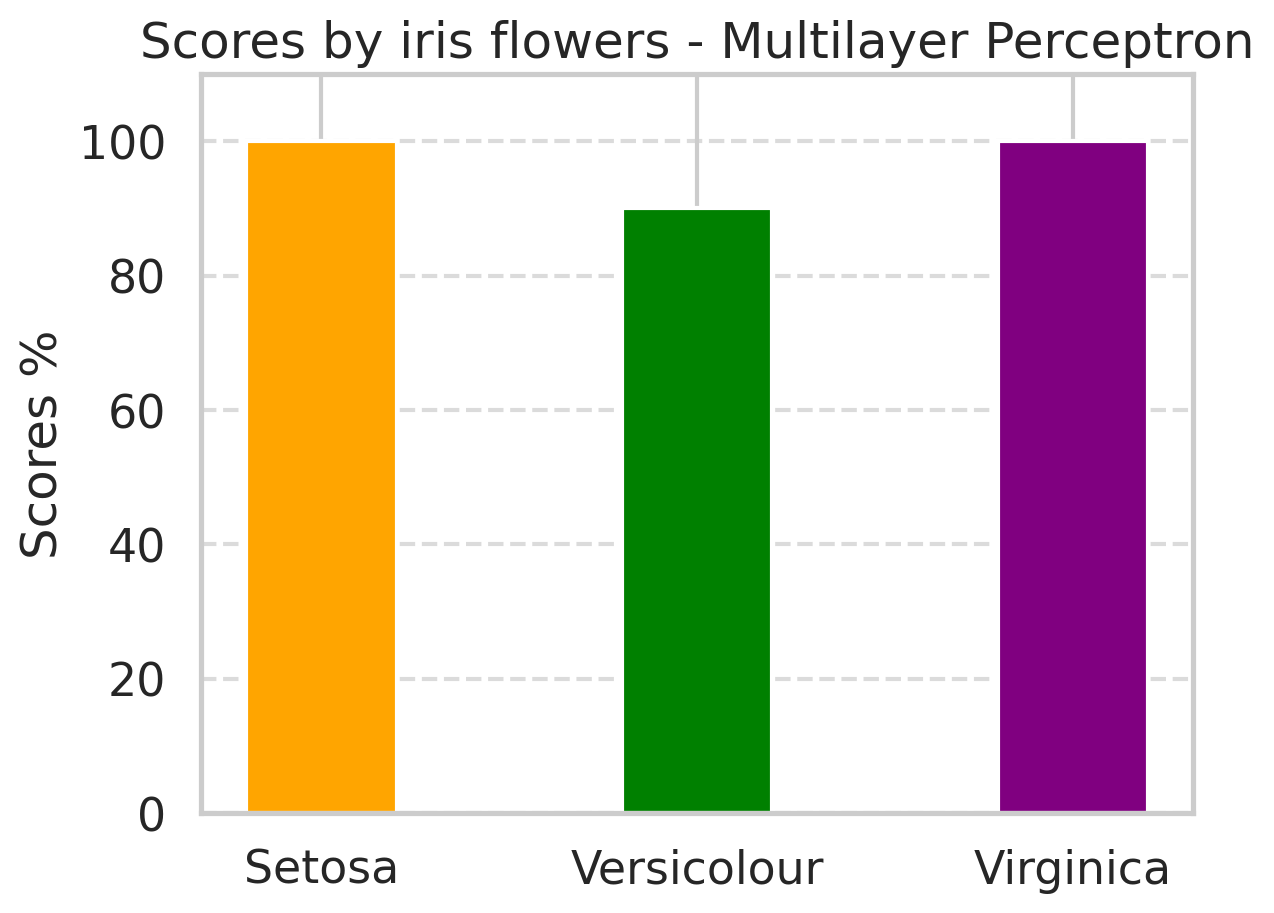

In [74]:
n_set = np.sum(y_test == 0)
n_vers = np.sum(y_test == 1)
n_virg = np.sum(y_test == 2)

score_set = np.sum((y_test == 0) & (test_predictions == 0))
score_vers = np.sum((y_test == 1) & (test_predictions == 1))
score_virg = np.sum((y_test == 2) & (test_predictions == 2))

acc_set = (score_set / n_set * 100) if n_set > 0 else 0
acc_vers = (score_vers / n_vers * 100) if n_vers > 0 else 0
acc_virg = (score_virg / n_virg * 100) if n_virg > 0 else 0

print("- Acurracy Iris-Setosa:","%.2f"%acc_set, "%")
print("- Acurracy Iris-Versicolour:","%.2f"%acc_vers, "%")
print("- Acurracy Iris-Virginica:","%.2f"%acc_virg, "%")

names = ["Setosa","Versicolour","Virginica"]
x1 = [2.0,4.0,6.0]

fig, ax = plt.subplots()
r1 = plt.bar(x1[0], acc_set, color='orange', label='Iris-Setosa')
r2 = plt.bar(x1[1], acc_vers, color='green', label='Iris-Versicolour')
r3 = plt.bar(x1[2], acc_virg, color='purple', label='Iris-Virginica')

plt.ylabel('Scores %')
plt.xticks(x1, names)
plt.title('Scores by iris flowers - Multilayer Perceptron')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7) # adiciona um grid para facilitar a leitura
plt.show()